<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
from google.colab import files

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [90]:
# TASK (a): Predict CO2 Emission
# Dataset: FuelConsumption.csv

In [91]:
uploaded = files.upload()

Saving FuelConsumption.csv to FuelConsumption (5).csv


In [92]:
fuel_data = pd.read_csv("FuelConsumption.csv")

In [93]:
print("=== Fuel Consumption Dataset ===")
print(fuel_data.head(), "\n")
print("Columns available:", list(fuel_data.columns), "\n")

=== Fuel Consumption Dataset ===
   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33    

In [94]:
X_fuel = fuel_data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y_fuel = fuel_data['CO2EMISSIONS']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X_fuel, y_fuel, test_size=0.2, random_state=42)

In [96]:
model_fuel = LinearRegression()
model_fuel.fit(X_train, y_train)

LinearRegression()

In [97]:
y_pred_fuel = model_fuel.predict(X_test)

In [98]:
r2_fuel = r2_score(y_test, y_pred_fuel)
mse_fuel = mean_squared_error(y_test, y_pred_fuel)
mae_fuel = mean_absolute_error(y_test, y_pred_fuel)

In [99]:
print("=== Fuel CO₂ Emission Model Performance ===")
print(f"R² Score: {r2_fuel:.4f}")
print(f"MSE: {mse_fuel:.2f}")
print(f"MAE: {mae_fuel:.2f}\n")

=== Fuel CO₂ Emission Model Performance ===
R² Score: 0.8760
MSE: 512.86
MAE: 16.72



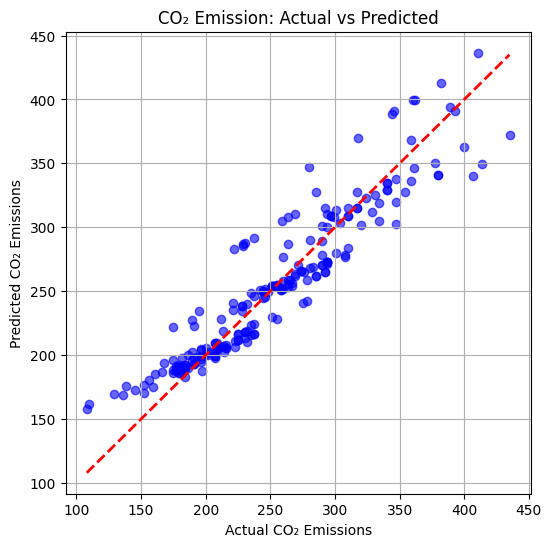

In [100]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_fuel, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("CO₂ Emission: Actual vs Predicted")
plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.grid(True)
plt.show()

In [101]:
# TASK (b): Predict Used Car Selling Price
# Dataset: used_cars_dataset.csv

In [102]:
uploaded = files.upload()

Saving used_cars.csv to used_cars (5).csv


In [103]:
used_car_data = pd.read_csv("used_cars.csv")

In [104]:
print("=== Used Cars Dataset ===")
print(used_car_data.head(), "\n")
print("Columns available:", list(used_car_data.columns), "\n")


=== Used Cars Dataset ===
   id      brand       model  year  miles  city_mileage  highway_mileage  \
0   3  Chevrolet     Volt LT  2019  27173            43               42   
1   6    Hyundai  Elantra SE  2017  76941            29               38   
2   7       Ford       Focus  2014  97027            27               37   
3   8      Honda       Civic  2016  95396            31               42   
4   9    Hyundai  Elantra SE  2019  28405            29               38   

   horsepower  torque  engine_capacity_litre  ...   type  doors  wheel_drive  \
0         149     294                    1.5  ...  sedan      4            2   
1         146     132                    2.0  ...  sedan      4            2   
2         159     146                    2.0  ...  sedan      4            2   
3         158     138                    1.5  ...  sedan      4            2   
4         147     132                    2.0  ...  sedan      4            2   

           engine_type  speed_levels

In [105]:
used_car_data.columns = used_car_data.columns.str.strip().str.lower()

In [106]:
X = used_car_data[['year', 'miles', 'horsepower', 'num_cylinder', 'num_owners']]
y = used_car_data['price']

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [109]:
y_pred = model.predict(X_test)

In [110]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


In [111]:
print("=== Used Car Price Model Performance ===")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}\n")

=== Used Car Price Model Performance ===
R² Score: -0.3324
MSE: 8062433.58
MAE: 2346.40



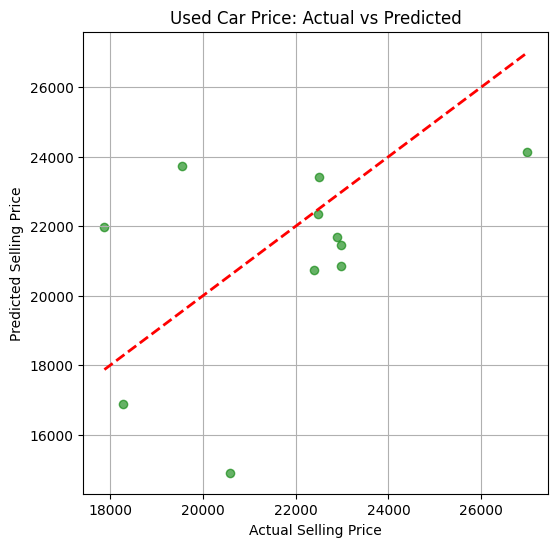

In [112]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Used Car Price: Actual vs Predicted")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.grid(True)
plt.show()